<a href="https://colab.research.google.com/github/SonuChaudhary9756/mnist-digit-classifier/blob/main/MNIST_Digit_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle

In [ ]:
import tensorflow as tf
from tensorflow import keras

(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

print("Dataset load ho gaya! ✅")
print("Training images:", train_images.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset load ho gaya! ✅
Training images: (60000, 28, 28)


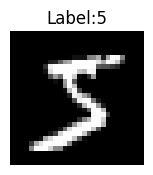

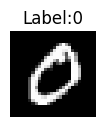

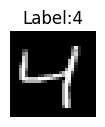

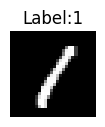

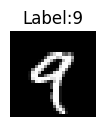

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,2))
for i in range(5):
  plt.subplot(1, 5, i+1)
  plt.imshow(train_images[i], cmap='gray')
  plt.title(f"Label:{train_labels[i]}")
  plt.axis('off')
  plt.show()

In [ ]:
# Pixel values ko 0-1 ke beech laate hain
train_images = train_images / 255.0
test_images = test_images / 255.0

print("Data ready ✅")

Data ready ✅


In [ ]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
print("model is completed ")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


model is completed 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
print("model is compiled")

model is compiled


In [ ]:
history = model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9275 - loss: 0.2568
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9668 - loss: 0.1128
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9768 - loss: 0.0772
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9819 - loss: 0.0587
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9855 - loss: 0.0464


In [ ]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9779 - loss: 0.0721
Test Accuracy: 0.9779000282287598


In [ ]:
from google.colab import files
from PIL import Image
import numpy as np

uplaoded = files.upload()

Saving Untitled.png to Untitled (1).png


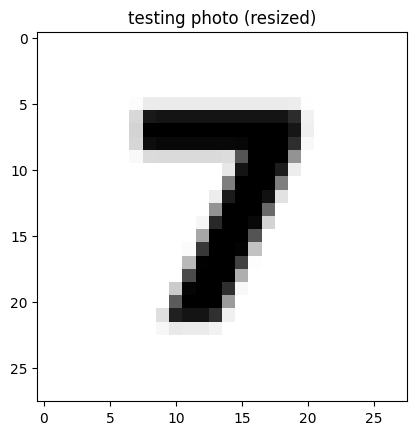

In [ ]:

filename = "Untitled.png"


img = Image.open(filename).convert('L')
img = img.resize((28, 28))


plt.imshow(img, cmap='gray')
plt.title("testing photo (resized)")
plt.show()

In [ ]:
# Photo ko model ke format mein taiyaar karo
img_array = np.array(img)
img_array = img_array / 255.0  # normalize (jaise pehle training data kiya tha)

# Colors ulta karna padega (MNIST mein white digit, black background hota hai)
img_array = 1 - img_array

# Model ko batana ki yeh "1 photo" hai
img_array = img_array.reshape(1, 28, 28)

# Prediction karo
prediction = model.predict(img_array)
predicted_digit = np.argmax(prediction)

print("Model ne predict kiya:", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Model ne predict kiya: 7
